In [1]:
import pandas as pd
import numpy as np
import importlib
import jenkspy
from tqdm import tqdm

from scipy.cluster.hierarchy import linkage, fcluster
# from scipy.conftest import xp_available_backends
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score
from scipy.stats import energy_distance
import kmedoids


import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import utility_functions as uf

In [2]:
df_cs_yearly = pd.read_csv(uf.PATH+"df_cs_yearly.csv", index_col = [0, 1, 2]).xs("individual", level=2)
df_prob_yearly = df_cs_yearly.div(df_cs_yearly.sum(axis=1), axis=0)

n_years = 5

df_cs_yearly = (
    df_cs_yearly
    .sort_index()
    .groupby(level=0)
    .rolling(n_years).sum()
    .reset_index(level=0, drop=True)
)
df_prob_yearly = df_cs_yearly.div(df_cs_yearly.sum(axis=1), axis=0)

df_dist_yearly = pd.read_csv(uf.PATH+"df_dist_w1_rolling_yearly_individual.csv", index_col=[0, 1])

In [3]:
df_cutoff = (
    pd.DataFrame({}, index=df_cs_yearly.index)
    .assign(
        total = df_cs_yearly.sum(axis=1),
        cutoff_5000 = lambda df: (df.total >= 5000).astype(int),
        cutoff_1000 = lambda df: (df.total >= 1000).astype(int),
    )
)

# Individual year

In [111]:
year = 2020

cutoff = 2000
param = "total"

country_idx = df_cutoff.xs(year, level=1).query(param+f" >= @cutoff").index.to_list()
df_cs = df_cs_yearly.xs(year, level=1).loc[country_idx]


df_prob = df_cs.div(df_cs.sum(axis=1), axis=0)

subfield_tree = uf.get_subfield_tree(uf.df_topics)

df_dist = df_dist_yearly.xs(year, level=1).loc[country_idx, country_idx]

np.fill_diagonal(df_dist.values, np.nan)

In [112]:
df_cs_example = df_cs
df_example = df_dist

In [113]:
D = df_example.fillna(0).values

param_value = 3

np.random.seed(0)
c = kmedoids.fasterpam(D, param_value)
# print("Loss is:", c.loss)

labels = c.labels
medoids = df_example.index[c.medoids].to_list()

print("Clusters: ")
print(pd.Series(labels).value_counts())
print()

print("Silhouette Score: ", silhouette_score(D, labels, metric="precomputed"))
print("Dunn Index: ", uf.dunn_index(df_example, labels))

Clusters: 
2    46
0    31
1    30
Name: count, dtype: int64

Silhouette Score:  0.29632886894550337
Dunn Index:  0.06928310994770857


In [114]:
(df_map,
 df_prob_clusters,
 df_dist_clusters,
 df_prob_medoids) = uf.get_cluster_data(labels, medoids, df_example, df_cs)

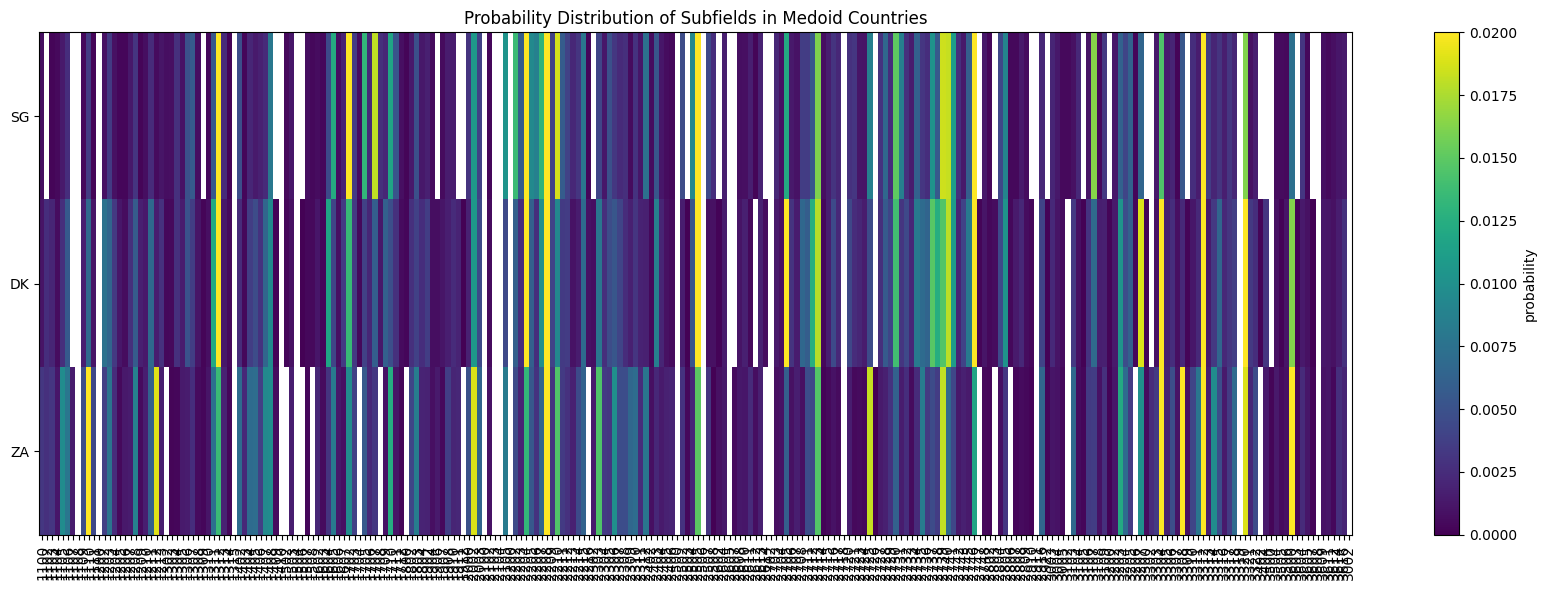

In [115]:
uf.plot_heatmap(
    df_prob_medoids,
    x_labels=df_prob_medoids.columns,
    y_labels=df_prob_medoids.index,
    title="Probability Distribution of Subfields in Medoid Countries",
    legend_label="probability",
    z_min=0, z_max=0.02,
)

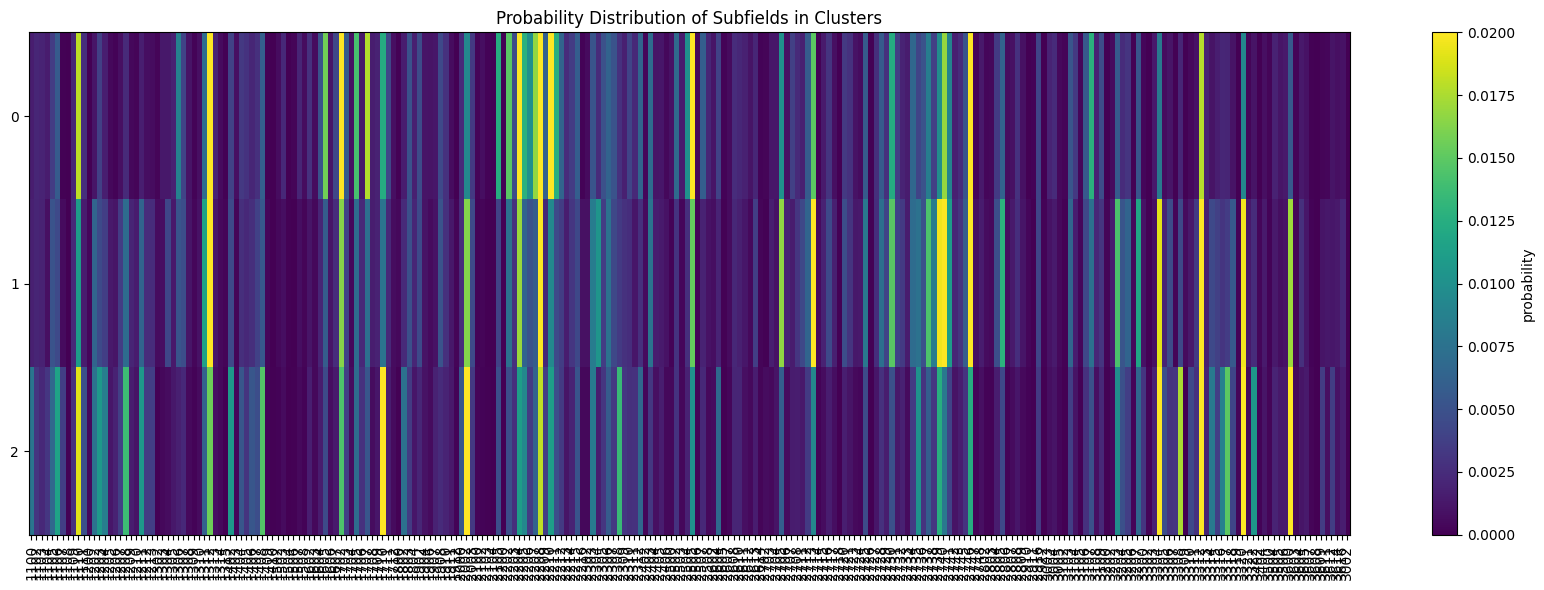

In [116]:
uf.plot_heatmap(
    df_prob_clusters,
    x_labels=df_prob_clusters.columns,
    y_labels=df_prob_clusters.index,
    title="Probability Distribution of Subfields in Clusters",
    legend_label="probability",
    z_min=0, z_max=0.02,
)

In [117]:
df_dist_clusters

,0,1,2
0,0.000000,0.219443,0.311472
1,0.219443,0.000000,0.182960
2,0.311472,0.182960,0.000000


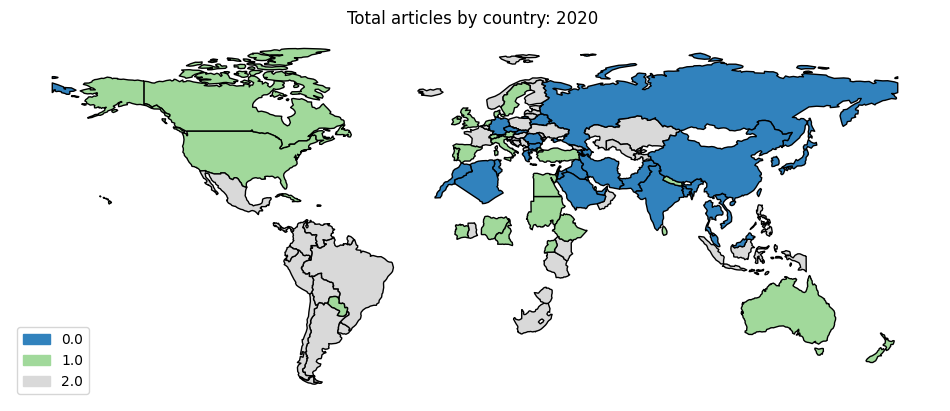

In [ ]:
_, _ = uf.plot_map_discrete(df_map, "cluster", country_column="country3", title=f"Total articles by country: {year}")

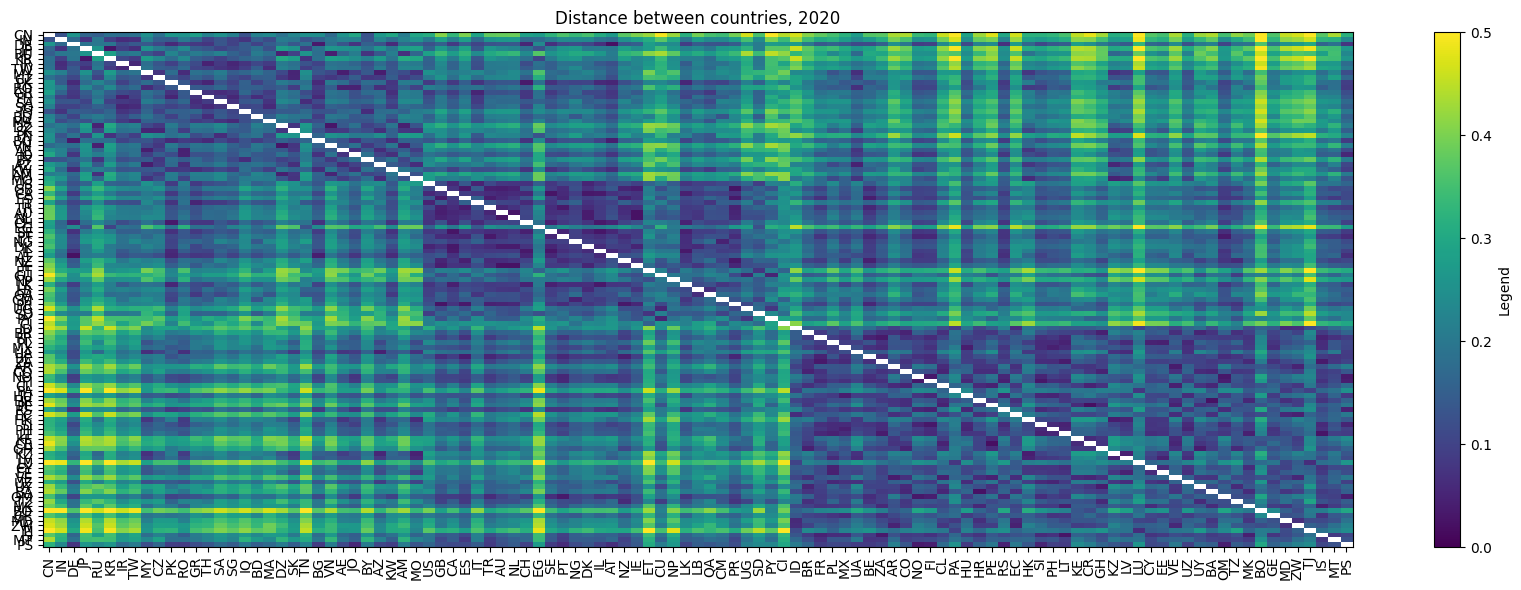

In [119]:
country_labels = df_map.sort_values(["cluster", "total_articles"], ascending=[True, False])["country"].to_list()

uf.plot_heatmap(
    df_example.loc[country_labels, country_labels],
    x_labels=country_labels,
    y_labels=country_labels,
    z_min=0, z_max=0.5,
    title=f"Distance between countries, {year}",
)

# Test artificial distribution clustering -- it seems to be non random

In [86]:
year = 2023

cutoff = 2000
param = "total"

df_cs_original = df_cs_yearly.xs(year, level=1)

n_subfields = len(df_cs_original.columns)
country_idx = df_cutoff.xs(year, level=1).query(param+f" >= @cutoff").index.to_list()

n_articles_by_country = df_cutoff.xs(year, level=1).loc[country_idx].total

df_cs_original = df_cs_yearly.xs(year, level=1).loc[country_idx]

Clusters: 
1    89
0    27
Name: count, dtype: int64

Silhouette Score:  0.37361086675109784
Dunn Index:  0.08239385390622347


/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_2176/4273576617.py:33: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



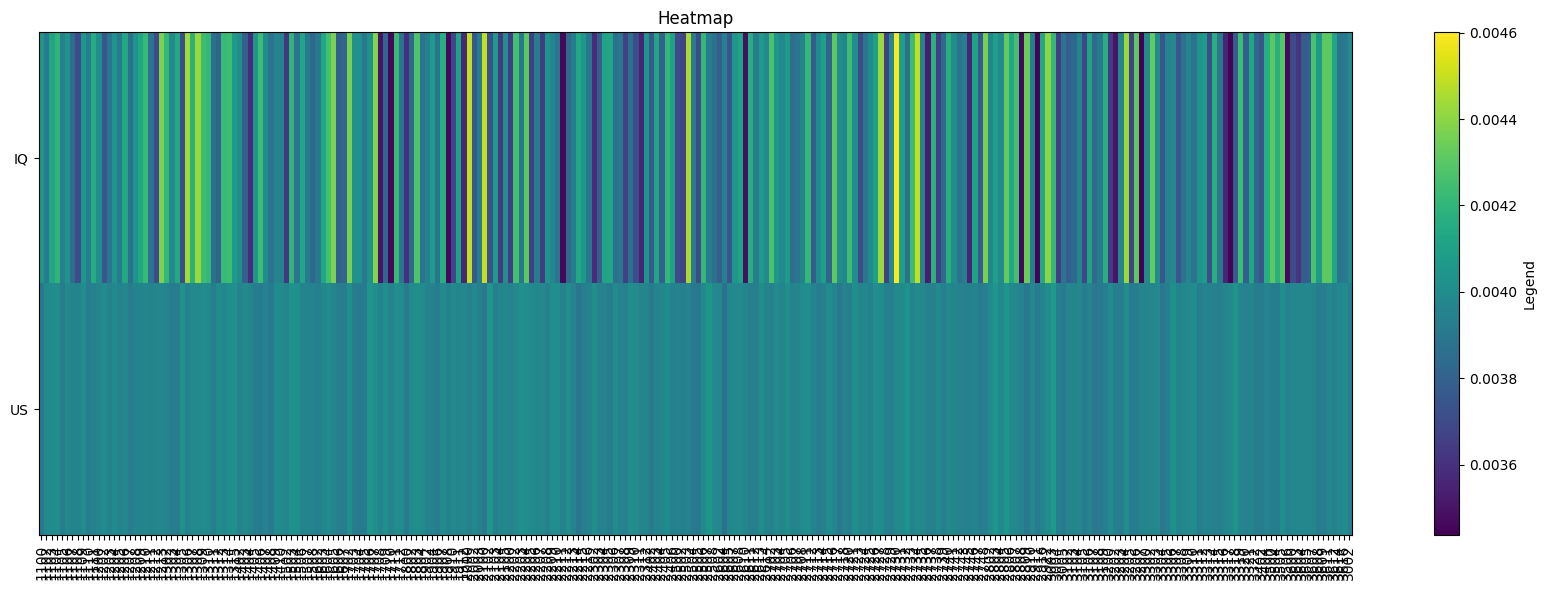

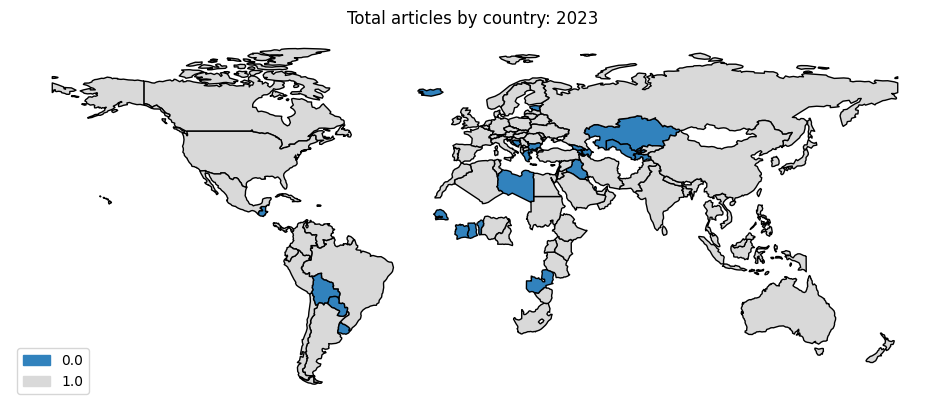

In [88]:
n_articles_by_country = df_cutoff.xs(year, level=1).loc[country_idx].total

df_cs_uniform = pd.DataFrame({}, index=df_cs_original.index, columns=df_cs_original.columns)
for country in country_idx:
    df_cs_uniform.loc[country] = pd.Series(np.random.choice(df_cs_original.columns,
                                                            int(n_articles_by_country.loc[country]),
                                                            p = np.ones(n_subfields) / n_subfields)).value_counts()

df_dist_uniform = uf.get_w1_distances(subfield_tree, df_cs_uniform.div(df_cs_uniform.sum(axis=1), axis=0))
D = df_dist_uniform.fillna(0).values

param_value = 2

np.random.seed(0)
c = kmedoids.fasterpam(D, param_value)
# print("Loss is:", c.loss)

labels = c.labels
medoids = df_dist_uniform.index[c.medoids].to_list()

print("Clusters: ")
print(pd.Series(labels).value_counts())
print()

print("Silhouette Score: ", silhouette_score(D, labels, metric="precomputed"))
print("Dunn Index: ", uf.dunn_index(df_dist_uniform, labels))

(df_map,
 df_prob_clusters,
 df_dist_clusters,
 df_prob_medoids) = uf.get_cluster_data(labels, medoids, df_dist_uniform, df_cs_uniform)

_ = uf.plot_heatmap(df_prob_medoids.fillna(0), x_labels=df_prob_medoids.columns, y_labels=df_prob_medoids.index)

_, _ = uf.plot_map_discrete(df_map, "cluster", country_column="country3", title=f"Total articles by country: {year}")

Clusters: 
1    96
0    20
Name: count, dtype: int64

Silhouette Score:  0.3675995881894166
Dunn Index:  0.08431889599824606


/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_2176/260989472.py:36: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



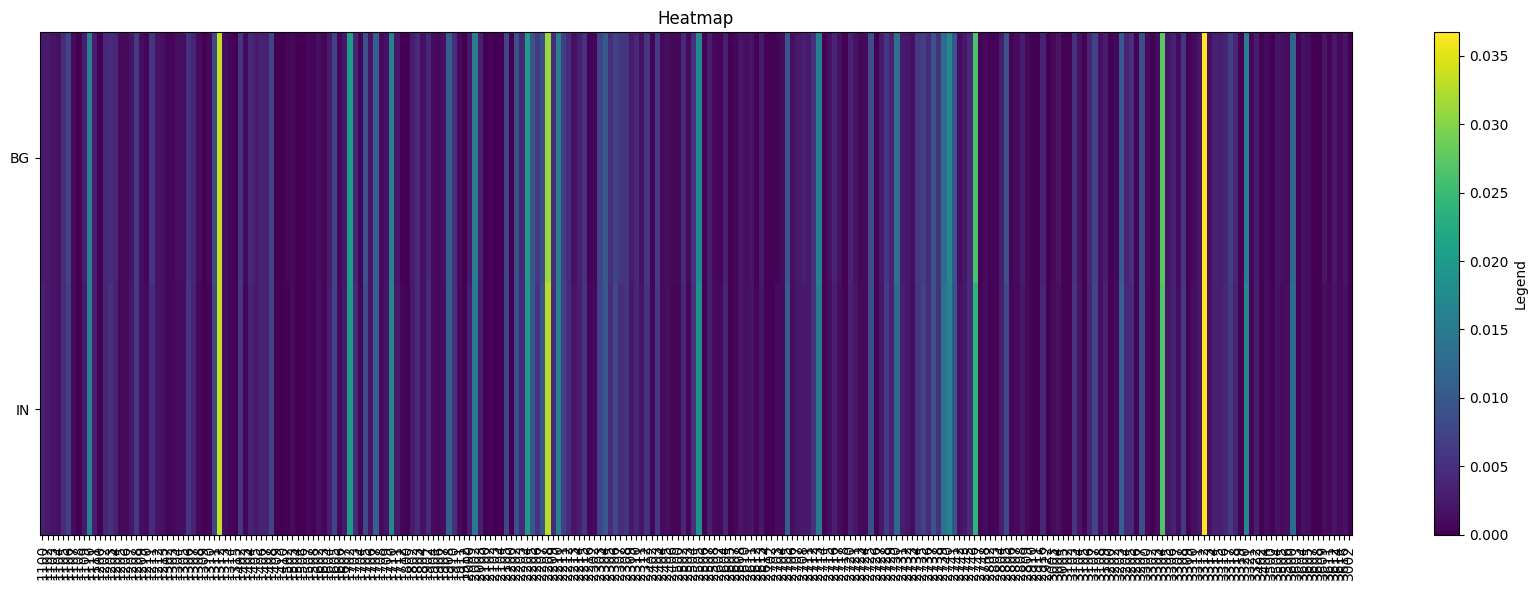

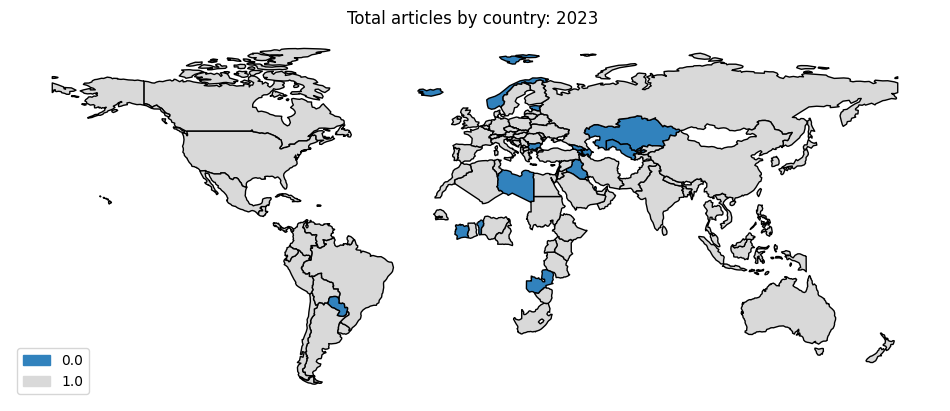

In [93]:
df_cs_global = df_cs_original.sum().to_frame("Global").T
df_probs_global = df_cs_global.div(df_cs_global.sum(axis=1), axis=0)

n_articles_by_country = df_cutoff.xs(year, level=1).loc[country_idx].total

df_cs_global = pd.DataFrame({}, index=df_cs_original.index, columns=df_cs_original.columns)
for country in country_idx:
    df_cs_global.loc[country] = pd.Series(np.random.choice(df_cs_original.columns,
                                                            int(n_articles_by_country.loc[country]),
                                                            p = df_probs_global.loc["Global"])).value_counts()

df_dist_global = uf.get_w1_distances(subfield_tree, df_cs_global.div(df_cs_global.sum(axis=1), axis=0))
D = df_dist_global.fillna(0).values

param_value = 2

np.random.seed(0)
c = kmedoids.fasterpam(D, param_value)
# print("Loss is:", c.loss)

labels = c.labels
medoids = df_dist_global.index[c.medoids].to_list()

print("Clusters: ")
print(pd.Series(labels).value_counts())
print()

print("Silhouette Score: ", silhouette_score(D, labels, metric="precomputed"))
print("Dunn Index: ", uf.dunn_index(df_dist_global, labels))

(df_map,
 df_prob_clusters,
 df_dist_clusters,
 df_prob_medoids) = uf.get_cluster_data(labels, medoids, df_dist_global, df_cs_global)

_ = uf.plot_heatmap(df_prob_medoids.fillna(0), x_labels=df_prob_medoids.columns, y_labels=df_prob_medoids.index)

_, _ = uf.plot_map_discrete(df_map, "cluster", country_column="country3", title=f"Total articles by country: {year}")

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_2176/965429499.py:6: RuntimeWarning:

invalid value encountered in cast



Clusters: 
1    94
0    22
Name: count, dtype: int64

Silhouette Score:  0.38923850331733256
Dunn Index:  0.05530006109527982


/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_2176/965429499.py:45: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



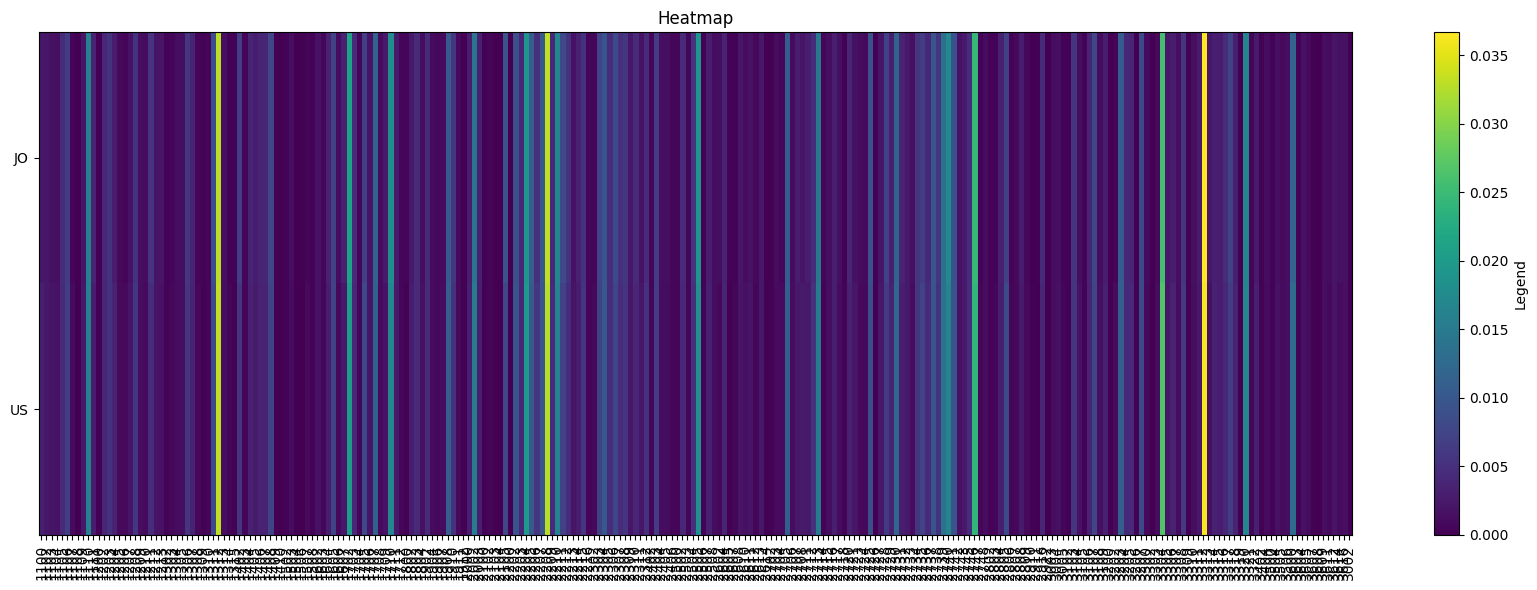

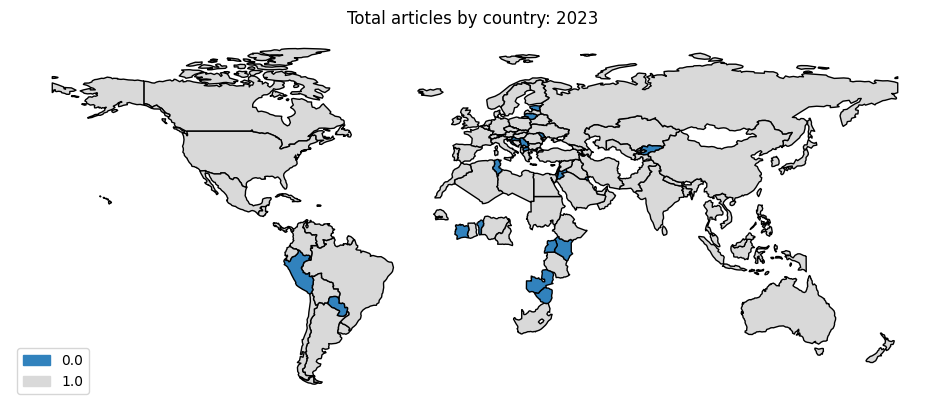

In [92]:
df_cs_permutation = pd.DataFrame({}, index=df_cs_original.index, columns=df_cs_original.columns)

df_original_articles = df_cs_original.melt()
n_articles_by_country = df_cutoff.xs(year, level=1).loc[country_idx].total.values.astype(int)

result = np.repeat(df_original_articles["variable"].values, df_original_articles["value"].values.astype(int))

rng = np.random.default_rng()
arr_shuffled = rng.permutation(result)

cuts = np.cumsum(n_articles_by_country)
starts = np.concatenate(([0], cuts[:-1]))

samples = [arr_shuffled[s:e] for s, e in zip(starts, cuts)]

for i, country in enumerate(country_idx):
    df_cs_permutation.loc[country] = pd.Series(samples[i]).value_counts()



df_dist_permutation = uf.get_w1_distances(subfield_tree, df_cs_permutation.div(df_cs_permutation.sum(axis=1), axis=0))
D = df_dist_permutation.fillna(0).values

param_value = 2

np.random.seed(0)
c = kmedoids.fasterpam(D, param_value)
# print("Loss is:", c.loss)

labels = c.labels
medoids = df_dist_permutation.index[c.medoids].to_list()

print("Clusters: ")
print(pd.Series(labels).value_counts())
print()

print("Silhouette Score: ", silhouette_score(D, labels, metric="precomputed"))
print("Dunn Index: ", uf.dunn_index(df_dist_permutation, labels))

(df_map,
 df_prob_clusters,
 df_dist_clusters,
 df_prob_medoids) = uf.get_cluster_data(labels, medoids, df_dist_permutation, df_cs_permutation)

_ = uf.plot_heatmap(df_prob_medoids.fillna(0), x_labels=df_prob_medoids.columns, y_labels=df_prob_medoids.index)

_, _ = uf.plot_map_discrete(df_map, "cluster", country_column="country3", title=f"Total articles by country: {year}")

# Yearly analysis

In [95]:
# get raw mapping

start_year = 1970
end_year = 2023

kmin = 2
kmax = 5

subfield_tree = uf.get_subfield_tree(uf.df_topics)

df_map_yearly_list = []
medoid_list = []

cutoff = 2000

param_value = 4
# switch_years = {1998: 3}

silhouette_list = []
medoid_silhouette_list = []

for year_loop in range(start_year, end_year+1):
    country_idx = df_cutoff.xs(year_loop, level=1).query(f"total >= @cutoff").index.to_list()
    # df_cs = df_cs_yearly.xs(year, level=1).loc[country_idx]
    # country_idx = df_cs_roll_yearly.xs(year_loop, level=1).sum(axis=1).to_frame("total").query("total >= @cap_articles").index.to_list()
    
    df_dist_loop = (
        df_dist_yearly
        .xs(year_loop, level=1)
        .loc[country_idx, country_idx]
    )
    df_dist_loop = df_dist_loop.loc[df_dist_loop.index, df_dist_loop.index]
    D_loop = df_dist_loop.loc[df_dist_loop.index, df_dist_loop.index].fillna(0).values
    
    if df_dist_loop.empty:
        continue
    # param_value = switch_years.get(year_loop, param_value)
    
    dm = kmedoids.dynmsc(D_loop, kmax, kmin)
    param_value = dm.bestk
    
    c = kmedoids.fasterpam(D_loop, param_value, random_state=0)

    silhouette_list.append(kmedoids.silhouette(D_loop, c.labels)[0])
    medoid_silhouette_list.append(kmedoids.medoid_silhouette(D_loop, c.medoids)[0])

    for i in range(param_value):
        medoid_list.append({"year": year_loop, "medoid": df_dist_loop.index[c.medoids].tolist()[i], "cluster": i})

    labels = c.labels
    df_map_yearly_list.append((
        pd.DataFrame(labels, index=df_dist_loop.index, columns=["cluster"])
        .assign(year=year_loop)
        .reset_index(names="country")
    ))

df_map_yearly = pd.concat(df_map_yearly_list)
df_medoids = pd.json_normalize(medoid_list)
# df_map_yearly.to_csv(uf.PATH+f"df_map_{param_value}_medoids_yearly_short_w1_{mode}.csv", index=False)

In [96]:
# clean clusters for all years

df_map_clean_yearly_list = []
df_medoids_clean_yearly_list = []
df_map_prev = df_map_yearly.query("year == @start_year").drop(columns=["year"]).set_index("country")
for year_loop in range(start_year+1, end_year+1):
    
    df_map_cur = df_map_yearly.query("year == @year_loop").drop(columns=["year"]).set_index("country")
    # display(df_map_cur)
    # display(df_map_prev)

    df_map_cur_clean, df_medoids_cur_clean = uf.clean_clusters(df_map_cur, df_map_prev, df_medoids.query("year == @year_loop").drop(columns=["year"]))
    df_map_clean_yearly_list.append(df_map_cur_clean.assign(year=year_loop).reset_index(names="country"))
    df_medoids_clean_yearly_list.append(df_medoids_cur_clean.assign(year=year_loop))    
    df_map_prev = df_map_cur_clean
df_map_clean_yearly = pd.concat(df_map_clean_yearly_list)
df_medoids_clean_yearly = pd.concat(df_medoids_clean_yearly_list)

# df_map_clean_yearly.to_csv(uf.PATH+f"df_map_{param_value}_short_clean_yearly_w1_{mode}.csv", index=False)
# df_medoids_clean_yearly.to_csv(uf.PATH+f"df_medoids_{param_value}_short_medoids_clean_yearly_w1_{mode}.csv", index=False)

In [97]:
df_cluster_prob_yearly_list = []

for year_loop in range(start_year, end_year+1):
    df_cs_loop = df_cs_yearly.xs(year, level=1)
    df_cluster_prob = uf.get_cluster_probabilities(df_map_clean_yearly.query("year==@year_loop"), df_cs_loop)
    df_cluster_prob_yearly_list.append(df_cluster_prob.assign(year=year_loop).reset_index(names="cluster"))
df_cluster_prob_yearly = pd.concat(df_cluster_prob_yearly_list)
# df_cluster_prob_yearly.to_csv(uf.PATH+f"df_prob_{param_value}_medoid_short_yearly_w1_{mode}.csv", index=False)

In [98]:
df_stats_medoid = uf.get_medoid_stats(df_map_clean_yearly, df_medoids_clean_yearly, df_cs_yearly.reset_index(), df_dist_yearly.reset_index())
# df_stats_medoid.to_csv(uf.PATH+f"df_stats_{param_value}_medoid_short_yearly_w1_{mode}.csv", index=False)

In [99]:
pivot = df_map_clean_yearly.pivot(index="country", columns="year", values="cluster")
pivot

clusters = pivot.values

# Broadcasting comparison
same_cluster = clusters[:, None, :] == clusters[None, :, :]

# Count matches across years
co_membership = same_cluster.sum(axis=2)

# Convert back to dataframe
df_dist_clusters_yearly = 1 - pd.DataFrame(
    co_membership,
    index=pivot.index,
    columns=pivot.index
) / (end_year - start_year)

df_n_years = pd.DataFrame(
    co_membership,
    index=pivot.index,
    columns=pivot.index
)
df_dist_clusters_yearly = 1 - df_n_years.div(np.diagonal(df_n_years.values))

# df_dist_clusters_yearly.to_csv(uf.PATH+f"df_dist_countries_{param_value}_medoid_short_w1_{mode}.csv", index=True)

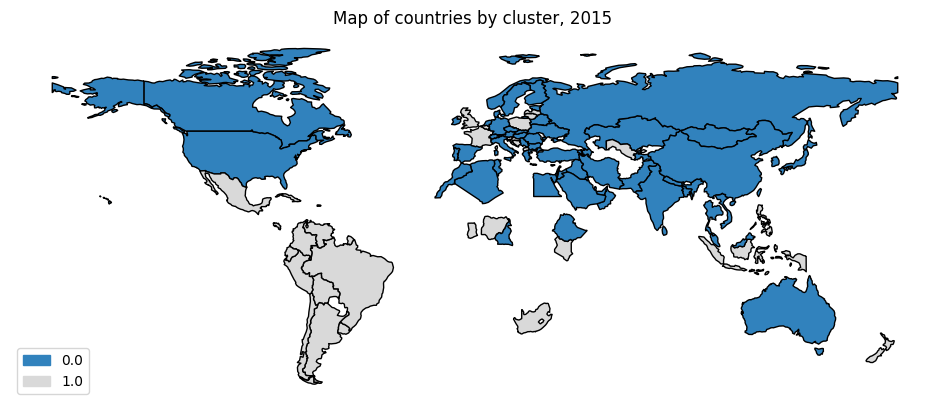

In [121]:
year = 2015
_, _ = uf.plot_map_discrete(
    df_map_clean_yearly.query("year==@year").merge(uf.df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2"),
    "cluster",
    title=f"Map of countries by cluster, {year}",
)

In [101]:
medoid_list = df_medoids_clean_yearly.set_index("year").loc[year].medoid.to_list()

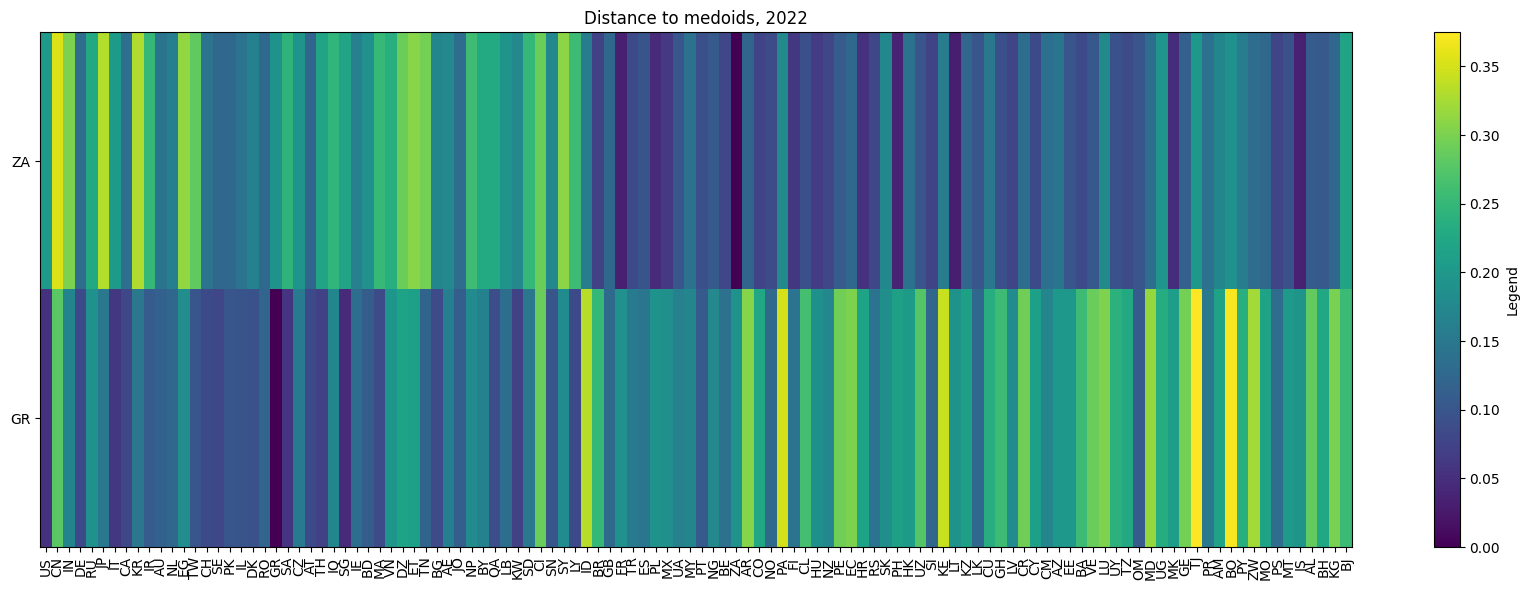

In [102]:
country_labels = (
    df_map_clean_yearly.query("year==@year")
    .merge(df_cs_yearly.xs(year, level=1).sum(axis=1).to_frame("total"),
           left_on="country", right_index=True, how="left")
    .sort_values(["cluster", "total"], ascending=[True, False])["country"].to_list()
)

# y_labels = df_cs.sum(axis=1).sort_values(ascending=False).index.to_list()
# y_labels = df_dist.index.to_list()
uf.plot_heatmap(
    df_dist_yearly.xs(year, level=1).loc[medoid_list, country_labels],
    x_labels=country_labels,
    y_labels=medoid_list,
    # z_min=0, z_max=1,
    # colorscale="non-symmetrical",
    # x_type="country",
    # y_type="country",
    title=f"Distance to medoids, {year}",
    # line_height=30
)

In [103]:
country_labels = (
    df_map_clean_yearly.query("year==@year")
    .merge(df_cs_yearly.xs(year, level=1).sum(axis=1).to_frame("total"),
           left_on="country", right_index=True, how="left")
    .sort_values(["cluster", "total"], ascending=[True, False])["country"].to_list()
)

# y_labels = df_cs.sum(axis=1).sort_values(ascending=False).index.to_list()
# y_labels = df_dist.index.to_list()
uf.plotly_heatmap(
    df_dist_yearly.xs(year, level=1).loc[country_labels, country_labels],
    x_labels=country_labels,
    y_labels=country_labels,
    # z_min=0, z_max=1,
    colorscale="non-symmetrical",
    x_type="country",
    y_type="country",
    title=f"Distance between countries, {year}",
    line_height=10
)

In [104]:
cluster = 1
df = (
    # pd.read_csv(uf.PATH+"df_prob_yearly.csv")
    df_prob_yearly
    # .query("mode == @mode")
    .merge(df_medoids_clean_yearly, left_index=True, right_on=["medoid", "year"], how="right")
    .query("cluster == @cluster")
    .drop(columns=["medoid", "cluster"])
    .set_index("year")
)
uf.plotly_heatmap(
    df,
    x_labels=df.columns,
    y_labels=df.index,
    x_type="subfield",
    title="Medoid probabilities for cluster {}".format(cluster),
    z_min=0, z_max=0.02,
    line_height=10, colorscale="non"
)

In [122]:
cluster = 1

df = df_cluster_prob_yearly.query("cluster == @cluster").drop(columns="cluster").set_index("year")

uf.plotly_heatmap(
    df, x_labels=df.columns, y_labels=df.index,
    title=f"Probability distribution of subfields in cluster {cluster} over time",  z_min=0, z_max=0.02, colorscale="non", line_height=10,
    x_type="subfield"
)

In [106]:
cluster1 = 0
cluster2 = 1

df0 = df_cluster_prob_yearly.query("cluster == @cluster1").drop(columns="cluster").set_index("year")
df1 = df_cluster_prob_yearly.query("cluster == @cluster2").drop(columns="cluster").set_index("year")

df = df0.sub(df1)

uf.plotly_heatmap(
    df, x_labels=df.columns, y_labels=df.index,
    title=f"Probability distribution of subfields in cluster {cluster1} minus cluster {cluster2} over time",
    z_min=-0.02, z_max=0.02, line_height=10,
    x_type="subfield"
)

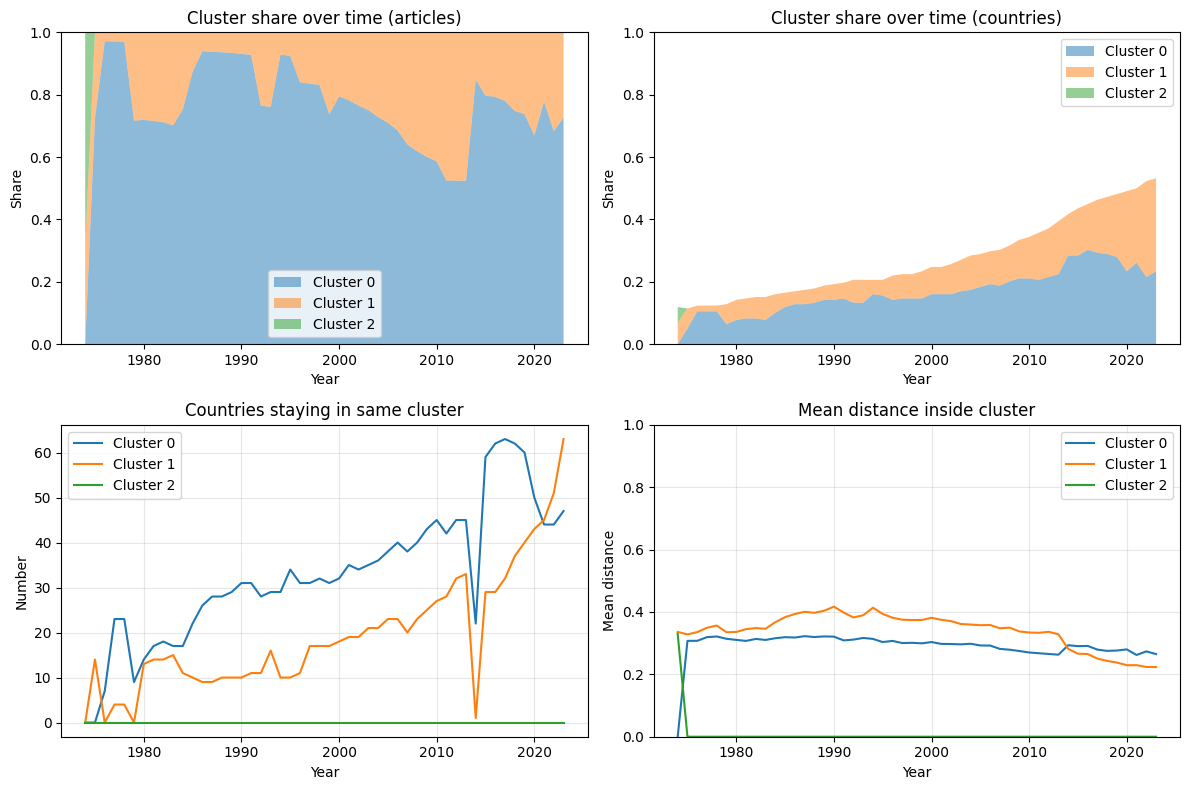

In [107]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# ==============================
# 1️⃣ Articles share (stacked)
# ==============================
pivot = df_stats_medoid.pivot(
    index="year", columns="cluster", values="total_articles_share"
).fillna(0)

axes[0, 0].stackplot(
    pivot.index,
    *pivot.values.T,
    labels=[f"Cluster {i}" for i in pivot.columns],
    alpha=0.5
)

axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_title("Cluster share over time (articles)")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Share")
axes[0, 0].legend()


# ==============================
# 2️⃣ Countries share (stacked)
# ==============================
pivot = df_stats_medoid.pivot(
    index="year", columns="cluster", values="countries_share"
).fillna(0)

axes[0, 1].stackplot(
    pivot.index,
    *pivot.values.T,
    labels=[f"Cluster {i}" for i in pivot.columns],
    alpha=0.5
)


axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_title("Cluster share over time (countries)")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Share")
axes[0, 1].legend()


# ==============================
# 3️⃣ Number stayed
# ==============================
pivot = df_stats_medoid.pivot(
    index="year", columns="cluster", values="n_stayed"
).fillna(0)

for cluster in pivot.columns:
    axes[1, 0].plot(pivot.index, pivot[cluster], label=f"Cluster {cluster}")

axes[1, 0].set_title("Countries staying in same cluster")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Number")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)


# ==============================
# 4️⃣ Mean distance
# ==============================
pivot = df_stats_medoid.pivot(
    index="year", columns="cluster", values="mean_distance"
).fillna(0)

for cluster in pivot.columns:
    axes[1, 1].plot(pivot.index, pivot[cluster], label=f"Cluster {cluster}")
# axes[1, 1].plot(range(start_year+1, end_year+1), mean_global, label="Global")

axes[1, 1].set_title("Mean distance inside cluster")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Mean distance")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)


plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Silhouette dynamics')

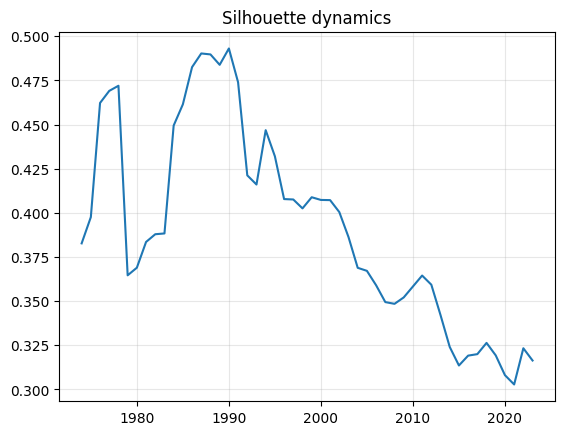

In [109]:
plt.plot(range(1974, 2024), silhouette_list)
plt.grid(alpha=0.3)
plt.title("Silhouette dynamics")

In [108]:
# years = range(start_year, end_year+1)

# fig, ax = plt.subplots(figsize=(12,6))

# animation = False

# anim = FuncAnimation(fig, animate_continuous, frames=years, interval=1000, blit=False)

# # Save as GIF
# # anim.save('map_animation.gif', writer='pillow', dpi=150)

# # Or save as MP4

# i += 1
# anim.save(f'../animations/clustering_short_medoids_{param_value}_w1_{mode}_{start_year}_{end_year}_{i}.mp4', writer='ffmpeg', dpi=150)